In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
target_file = '~/PheOpt/map_explore/target/covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26.csv'
aux_files = [
 '~/PheOpt/map_explore/auxiliary/covidcast-fb-survey-raw_wcli-2020-04-06-to-2022-06-25.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-fb-survey-raw_whh_cmnty_cli-2020-04-06-to-2022-06-25.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-fb-survey-smoothed_wtested_14d-2020-04-06-to-2022-06-25.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-fb-survey-smoothed_wtested_positive_14d-2020-04-06-to-2022-06-25.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s01_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s02_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s03_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s04_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s05_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s06_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s07_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/target/covidcast-jhu-csse-confirmed_incidence_num-2020-01-22-to-2023-03-09.csv',
 '~/PheOpt/map_explore/target/covidcast-jhu-csse-deaths_incidence_num-2020-01-22-to-2023-03-09.csv']
VALID_STATES = set(['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'])

In [2]:
target_file = '~/PheOpt/map_explore/target/covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26.csv'
# '~/PheOpt/map_explore/target/covidcast-dsew-cpr-confirmed_admissions_covid_1d_7dav-2020-12-16-to-2023-02-21.csv'
aux_files = [
 '~/PheOpt/map_explore/auxiliary/covidcast-fb-survey-raw_wcli-2020-04-06-to-2022-06-25.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-fb-survey-raw_whh_cmnty_cli-2020-04-06-to-2022-06-25.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-fb-survey-smoothed_wtested_14d-2020-04-06-to-2022-06-25.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-fb-survey-smoothed_wtested_positive_14d-2020-04-06-to-2022-06-25.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s01_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s02_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s03_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s04_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s05_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s06_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/auxiliary/covidcast-google-symptoms-s07_raw_search-2019-12-31-to-2024-04-26.csv',
 '~/PheOpt/map_explore/target/covidcast-jhu-csse-confirmed_incidence_num-2020-01-22-to-2023-03-09.csv',
 '~/PheOpt/map_explore/target/covidcast-jhu-csse-deaths_incidence_num-2020-01-22-to-2023-03-09.csv']
#  '~/PheOpt/map_explore/auxiliary/covidcast-chng-smoothed_outpatient_cli-2020-02-01-to-2024-02-14.csv',
#  '~/PheOpt/map_explore/auxiliary/covidcast-chng-smoothed_outpatient_covid-2020-02-01-to-2024-02-14.csv',
#  '~/PheOpt/map_explore/auxiliary/covidcast-doctor-visits-smoothed_cli-2020-02-01-to-2024-04-26.csv',

#  '~/PheOpt/map_explore/auxiliary/covidcast-quidel-covid_ag_raw_pct_positive-2020-05-26-to-2024-04-26.csv',

In [4]:
signal_wides = {}
for fp in [target_file]+aux_files:
    name = os.path.splitext(os.path.basename(fp))[0]
    if name == "fetch":
        continue
    print("Loading ", name)
    df = pd.read_csv(fp)
    df["time_value"] = pd.to_datetime(df["time_value"])
    df["geo_value"] = df["geo_value"].astype(str).str.upper()
    wide = df.pivot(index="time_value", columns="geo_value", values="value").sort_index()
    wide = wide.fillna(0.0)
    signal_wides[name] = wide
    print(sorted(set(signal_wides[name].columns)))

Loading  covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26
['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VI', 'VT', 'WA', 'WI', 'WV', 'WY']
Loading  covidcast-fb-survey-raw_wcli-2020-04-06-to-2022-06-25
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
Loading  covidcast-fb-survey-raw_whh_cmnty_cli-2020-04-06-to-2022-06-25
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS'

In [9]:
import os
import glob
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error
import celer

# =========================
# Aggregation: sparsity index candidate states + Q-aggregation on validation
# =========================
def estimate_R_hat_from_series(d0, dl, s: int):
    """
    Robust: handles pd.Series (preferred) and numpy arrays (fallback).
    If both are Series: align by feature names (intersection).
    Otherwise: align by common prefix length.
    """
    # Case 1: both are Series => align by feature name
    if hasattr(d0, "index") and hasattr(dl, "index"):
        common = d0.index.intersection(dl.index)
        if len(common) == 0:
            return np.inf
        Delta = (dl.loc[common] - d0.loc[common]).to_numpy()
        m = len(Delta)
    else:
        # Case 2: fallback to positional alignment
        d0 = np.asarray(d0, float).ravel()
        dl = np.asarray(dl, float).ravel()
        m = min(len(d0), len(dl))
        if m == 0:
            return np.inf
        Delta = dl[:m] - d0[:m]

    s = int(min(s, m))
    if s <= 0:
        return 0.0
    idx = np.argpartition(np.abs(Delta), -s)[-s:]
    return float(np.sum(Delta[idx] ** 2))

def select_candidate_states(d_by_state, target_state, all_states, s=300, K=10):
    d0 = d_by_state[target_state]
    scores = []
    for st in all_states:
        if st == target_state:
            continue
        if st not in d_by_state:
            continue
        R = estimate_R_hat_from_series(d0, d_by_state[st], s=s)
        scores.append((st, R))
    scores.sort(key=lambda x: x[1])
    return [st for st, _ in scores[:K]]

def q_aggregate_weights(y_val, Yhat_val, total_step=10, selection=False, eps=1e-3):
    """
    Q-aggregation in prediction space.

    Inputs
    ------
    y_val      : (n,) or (n,1) target validation outcomes
    Yhat_val   : (n, M) candidate predictions on validation set
    total_step : max iterations
    selection  : if True, pick single best candidate (one-hot weights)
    eps        : stopping tolerance on L1 change in weights

    Returns
    -------
    theta_hat  : (M,) weights on simplex
    """
    y = np.asarray(y_val, float).reshape(-1, 1)
    XB = np.asarray(Yhat_val, float)  # (n, M)
    n, M = XB.shape

    if M == 0:
        return np.array([], dtype=float)
    if M == 1:
        return np.array([1.0], dtype=float)

    # selection option: pick candidate with smallest MSE on validation
    if selection:
        mse = np.mean((y - XB) ** 2, axis=0)
        khat = int(np.argmin(mse))
        theta_hat = np.zeros(M, dtype=float)
        theta_hat[khat] = 1.0
        return theta_hat

    # initialize weights proportional to exp(-RSS/2)
    rss = np.sum((y - XB) ** 2, axis=0)  # (M,)
    # numerical stability
    a = -0.5 * rss
    a = a - np.max(a)
    theta_hat = np.exp(a)
    theta_hat /= theta_hat.sum()

    theta_old = theta_hat.copy()

    # initialize aggregated prediction
    beta_pred = XB @ theta_hat  # (n,)

    for _ in range(int(total_step)):
        Xbeta = beta_pred.reshape(-1, 1)  # (n,1)

        # theta <- exp(-RSS/2 + ||Xbeta - XB||^2 / 8)
        adj = np.sum((Xbeta - XB) ** 2, axis=0) / 8.0
        a = -0.5 * rss + adj
        a = a - np.max(a)  # stabilize
        theta_hat = np.exp(a)
        theta_hat /= theta_hat.sum()

        # beta <- 1/4 * (XB theta) + 3/4 * beta
        beta_new = (XB @ theta_hat) * 0.25 + 0.75 * beta_pred

        # stopping
        if np.sum(np.abs(theta_hat - theta_old)) < eps:
            beta_pred = beta_new
            break

        theta_old = theta_hat.copy()
        beta_pred = beta_new

    return theta_hat



# =========================
# Dataset construction
# =========================
def build_design_for_state(
    target_wide: pd.DataFrame,
    feature_wides: dict,
    state: str,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    feature_lags,
    ar_lags,
    unit
):
    """
    Build X,y for ONE state in [start_date, end_date] inclusive.
    X columns:
      - for each feature signal: values lagged by feature_lags (group = signal)
      - for target signal: AR lags by ar_lags (group = 'AR')
    Returns (X, y, dates, feature_names, group_names).
    """

    max_lag = max(max(feature_lags), max(ar_lags))
    start_ext = start_date - pd.Timedelta(max_lag, unit = unit)

    # base index
    idx = target_wide.loc[start_ext:end_date].index

    y_series = target_wide.loc[idx, state].copy()

    X_blocks = []
    feature_names = []
    group_names = []

    # exogenous features
    for sig_name, wide in feature_wides.items():
        if state not in wide.columns:
            continue
        s = wide.loc[idx, state].copy()
        for lag in feature_lags:
            X_blocks.append(s.shift(lag))
            feature_names.append(f"{sig_name}_lag{lag}")
        group_names.append(sig_name)

    # AR features (target lags)
    for lag in ar_lags:
        X_blocks.append(y_series.shift(lag))
        feature_names.append(f"AR_lag{lag}")
    group_names.append("AR")

    X_df = pd.concat(X_blocks, axis=1)
    X_df.columns = feature_names

    # keep only rows within [start_date, end_date] after shifting
    aligned = pd.concat([y_series.rename("y"), X_df], axis=1)
    aligned = aligned.loc[start_date:end_date].dropna()

    if len(aligned) == 0:
        return None

    y = aligned["y"].values.astype(float)
    X = aligned.drop(columns=["y"]).values.astype(float)
    dates = aligned.index

    return X, y, dates, feature_names, group_names


def compute_walkforward_schedule(dates, train_size, test_size, retrain_every, unit = 'd'):
    """
    Create monthly retraining points (train_end) so that:
      test_end = train_end + test_size is within data range
    train_end moves forward by retrain_every.
    """
    dates = pd.to_datetime(dates).sort_values()
    start = dates.min() + pd.Timedelta(train_size, unit)
    end = dates.max() - pd.Timedelta(test_size, unit)

    if start >= end:
        return []

    start = dates[dates.get_indexer([start], method="nearest")[0]]
    train_ends = []
    cur = start
    while cur <= end:
        train_ends.append(cur)
        cur = cur + pd.Timedelta(retrain_every, unit = unit)
    return train_ends

# =========================
# GroupLasso utilities (SIS + KKT)
# (mostly matching your earlier code; assumes equal group_size)
# =========================
def extend_indices(g_indices, group_size):
    g_indices = np.asarray(g_indices, dtype=int)
    v = (g_indices[:, None] * group_size + np.arange(group_size)[None, :]).ravel()
    return v.astype(int)

def shrink_indices(v_indices, group_size):
    v_indices = np.asarray(v_indices, dtype=int)
    return np.unique(v_indices // group_size).astype(int)

def standardize_xy(X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=0)
    X_std[X_std == 0] = 1.0
    Xz = (X - X_mean) / X_std

    y_mean = y.mean()
    y_std = y.std(ddof=0)
    if y_std == 0:
        y_std = 1.0
    yz = (y - y_mean) / y_std
    return Xz, yz, X_mean, X_std, y_mean, y_std

def recover_coefficients(unit_coef, X_std, y_std):
    X_std = np.asarray(X_std, dtype=float)
    return (y_std / X_std) * unit_coef

def recover_intercept(X, y, coef_original, X_mean=None, y_mean=None):
    if X_mean is None:
        X_mean = np.mean(X, axis=0)
    if y_mean is None:
        y_mean = np.mean(y)
    return float(y_mean - X_mean.dot(coef_original))

def SIS(X, y, nSel):
    X = np.asarray(X)
    y = np.asarray(y)

    y_std = y.std()
    if y_std == 0:
        return np.array([], dtype=int)

    corrs = np.zeros(X.shape[1])
    for j in range(X.shape[1]):
        xj = X[:, j]
        sx = xj.std()
        if sx == 0:
            corrs[j] = 0.0
        else:
            corrs[j] = abs(np.cov(xj, y, bias=True)[0, 1] / (sx * y_std))

    order = np.argsort(corrs)[::-1]
    return order[:nSel].astype(int)

def fit_grpLasso(Xz, yz, alpha, group_size, weights=None):
    model = celer.GroupLasso(
        groups=group_size,           # equal block size
        alpha=alpha,
        tol=1e-4,
        fit_intercept=False,
        weights=weights
    )
    model.fit(Xz, yz)
    return model, model.coef_.copy()

def check_KKT(Xz, yz, coef_unit_full, active_g_indices, group_size, alpha, weights=None, tol=1e-4):
    residual = yz - Xz.dot(coef_unit_full)
    p_groups = Xz.shape[1] // group_size
    stats = np.zeros(p_groups)

    for g in range(p_groups):
        j0 = g * group_size
        j1 = j0 + group_size
        Xg = Xz[:, j0:j1]
        stats[g] = np.linalg.norm(Xg.T.dot(residual), 2) / Xg.shape[0]

    thresh = alpha if weights is None else alpha * np.asarray(weights)
    violated = np.where(stats > (thresh + tol))[0]
    violated = list(set(violated) - set(np.asarray(active_g_indices, dtype=int)))
    violated.sort()
    return violated

def SIS_grpLasso_KKT(X_expanded, y, group_size, alpha, weights=None, sis_ratio=1.0, max_iter=50):
    n, p_exp = X_expanded.shape
    p_groups = p_exp // group_size

    Xz, yz, X_mean, X_std, y_mean, y_std = standardize_xy(X_expanded, y)

    # Always define this, even if SIS selects nothing
    coef_unit_full = np.zeros(p_exp, dtype=float)

    # fast group summary for SIS: RMS within each group
    X3 = Xz.reshape(n, p_groups, group_size)
    X_group = np.sqrt(np.mean(X3**2, axis=2))

    nSel = int(max(1, min(p_groups, np.floor((len(y) / group_size - 1) * sis_ratio))))
    violated_g = list(SIS(X_group, yz, nSel=nSel))

    # If SIS selects nothing, return intercept-only model
    if len(violated_g) == 0:
        coef = recover_coefficients(coef_unit_full, X_std, y_std)  # all zeros
        intercept = float(y_mean)  # y_mean - X_mean@0
        return np.array([], dtype=int), coef, intercept

    active_g = np.array([], dtype=int)

    it = 0
    while len(violated_g) > 0:
        it += 1
        if it > max_iter:
            break

        active_g = np.array(sorted(set(active_g) | set(violated_g)), dtype=int)
        SIS_v = extend_indices(active_g, group_size)

        _, coef_unit_sub = fit_grpLasso(
            Xz[:, SIS_v], yz, alpha=alpha, group_size=group_size, weights=weights
        )

        coef_unit_full[:] = 0.0
        coef_unit_full[SIS_v] = coef_unit_sub

        violated_g = check_KKT(
            Xz, yz, coef_unit_full, active_g, group_size, alpha, weights=weights
        )

    coef = recover_coefficients(coef_unit_full, X_std, y_std)
    intercept = recover_intercept(X_expanded, y, coef, X_mean=X_mean, y_mean=y_mean)

    active_v = np.where(coef != 0)[0]
    active_g_final = shrink_indices(active_v, group_size)
    return active_g_final, coef, intercept



# =========================
# Baseline: AR-only with exp-decay weights (choose gamma by validation)
# =========================
def weighted_ols_fit_predict(X_train, y_train, w_train, X_pred):
    X_train = np.asarray(X_train, float)
    y_train = np.asarray(y_train, float)
    w_train = np.asarray(w_train, float)
    X_pred  = np.asarray(X_pred,  float)

    Xtr = np.column_stack([np.ones(len(X_train)), X_train])
    Xpr = np.column_stack([np.ones(len(X_pred)),  X_pred])

    sw = np.sqrt(np.clip(w_train, 0.0, np.inf))
    Xw = Xtr * sw[:, None]
    yw = y_train * sw

    eps = 1e-8
    A = Xw.T @ Xw + eps * np.eye(Xw.shape[1])
    b = Xw.T @ yw
    beta = np.linalg.solve(A, b)
    return Xpr @ beta

def fit_ar_baseline_decay(X_train, y_train, X_val, y_val, train_dates, train_end, gammas):
    """
    Choose gamma that minimizes val MSE.
    train_dates: DatetimeIndex aligned with X_train/y_train rows
    train_end: Timestamp = last day in training window
    """
    train_end = pd.to_datetime(train_end)
    backcast_lag = (train_end - pd.to_datetime(train_dates)).days.astype(float).values

    best = None
    for g in gammas:
        w = np.exp(-g * backcast_lag)
        w = w / (w.max() if w.max() > 0 else 1.0)
        yhat_val = weighted_ols_fit_predict(X_train, y_train, w, X_val)
        mse = mean_squared_error(y_val, yhat_val)
        if best is None or mse < best["mse"]:
            best = {"gamma": g, "mse": mse}
    return best["gamma"]

def predict_named(X, feat_names_ref, coef_series, intercept):
    w = coef_series.reindex(feat_names_ref).fillna(0.0).to_numpy()
    return X @ w + intercept

0.03


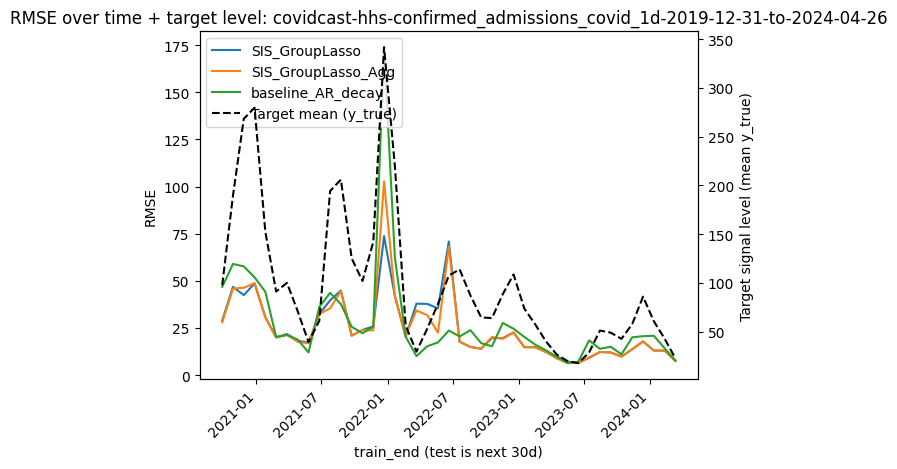

                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  29.268052  14.130497  69660.0  
1  30.446721  13.819450  69660.0  
2  38.421834  14.976074  69660.0  
0.05


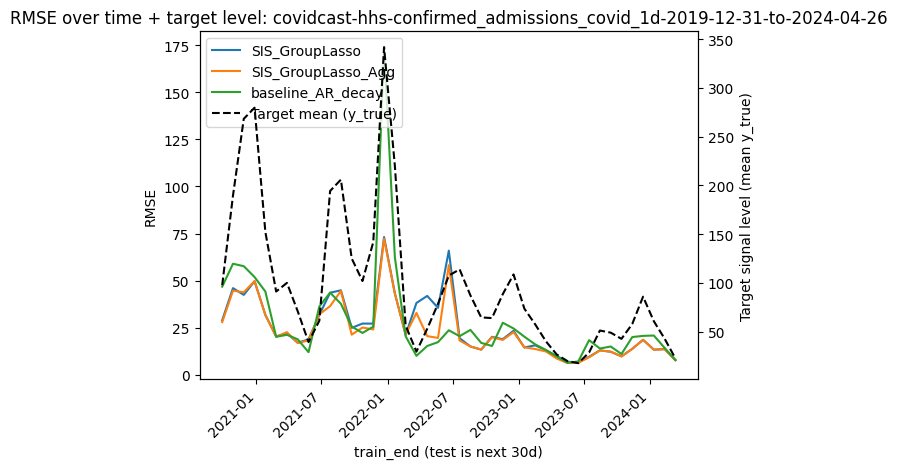

                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  29.574945  14.363512  69660.0  
1  27.550964  13.576531  69660.0  
2  38.421834  14.976074  69660.0  
0.07


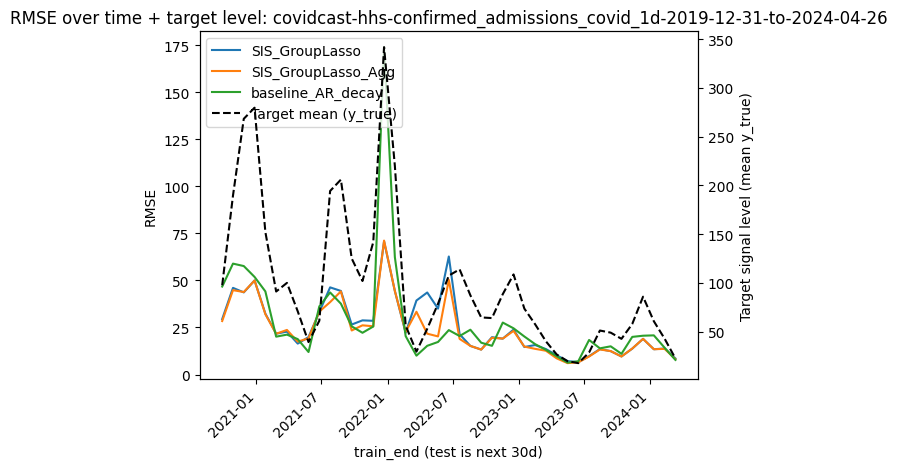

                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  29.849562  14.597838  69660.0  
1  27.604760  13.751342  69660.0  
2  38.421834  14.976074  69660.0  
0.1


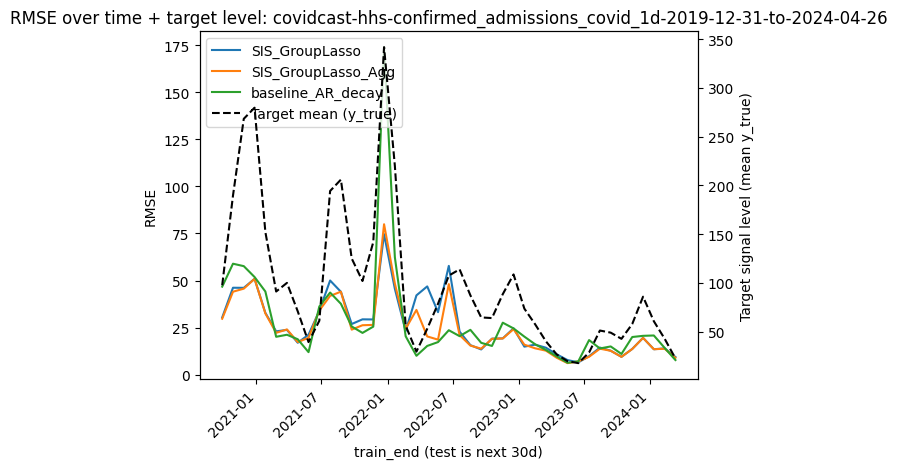

                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  30.542999  14.944883  69660.0  
1  28.627864  14.049966  69660.0  
2  38.421834  14.976074  69660.0  


In [15]:
FEATURE_LAGS = (1, 2, 3, 4)
AR_LAGS      = (1, 2, 3, 4)
BASELINE_GAMMAS = [0.0, 0.01, 0.05, 0.1]
K_CANDIDATES = 3
S_SCREEN = 50    # top-s entries in sparsity-index screening
Q_TAU = 1.0       # temperature for Q-aggregation
unit = 'D'
RETRAIN_EVERY = 30
TEST_WINDOW = 30
VAL_WINDOW = 30
TRAIN_WINDOW = 180
target_name = 'covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26'
target_wide = signal_wides[target_name].iloc[92:]
all_signal_wides = {}
for fp in aux_files:
    name = os.path.splitext(os.path.basename(fp))[0]
    all_signal_wides[name] = signal_wides[name]

target_wide = target_wide.sort_index()
target_idx = pd.to_datetime(target_wide.index)
feature_wides_raw = {k: v for k, v in all_signal_wides.items() if k != target_name}
feature_wides = {}
for sig_name, wide in feature_wides_raw.items():
    if wide is None or len(wide) == 0:
        continue
    wide = wide.sort_index().copy()
    wide.index = pd.to_datetime(wide.index)
    wide_aligned = wide.reindex(target_idx)
    wide_aligned = wide_aligned.mask(wide_aligned < 0, 0.0)
    # wide_aligned = wide_aligned.interpolate(method="time", limit=LIMIT_INTERP_DAYS, limit_area="inside")
    # wide_aligned = wide_aligned.ffill(limit=LIMIT_INTERP_DAYS).bfill(limit=LIMIT_INTERP_DAYS)
    wide_aligned = wide_aligned.fillna(0.0)
    nonconstant_cols = (wide_aligned.abs().sum(axis=0) > 0)
    wide_aligned = wide_aligned.loc[:, nonconstant_cols]
    if wide_aligned.shape[1] == 0:
        continue
    feature_wides[sig_name] = wide_aligned

# Determine states common across target + (at least some) features
states = [c for c in target_wide.columns if c.isalpha() and len(c) == 2]  # typical state abbrev
states = [st for st in states if st in target_wide.columns]
if len(states) == 0:
    states = list(target_wide.columns)

train_ends = compute_walkforward_schedule(dates = target_wide.index, train_size = TRAIN_WINDOW, test_size = TEST_WINDOW, retrain_every = RETRAIN_EVERY, unit = unit)

group_size = len(FEATURE_LAGS)
assert len(AR_LAGS) == group_size, "AR_LAGS must have same length as FEATURE_LAGS for equal-size groups."

for GL_ALPHA in [0.03, 0.05, 0.07, 0.1]:
    pred_rows = []
    agg_rows = []
    for train_end in train_ends:
        train_end = pd.to_datetime(train_end)
        train_start = train_end - pd.Timedelta(TRAIN_WINDOW - 1, unit = unit)
        val_start = train_end - pd.Timedelta(VAL_WINDOW - 1, unit = unit)
        test_start = train_end + pd.Timedelta(1, unit = unit)
        test_end = train_end + pd.Timedelta(TEST_WINDOW, unit = unit)

        # Fit GroupLasso for ALL states in this window (target-only training per state)
        # Store coefs/intercepts and d = X^T y / T for candidate selection
        fit_by_state = {}
        d_by_state = {}

        # also store AR-only baseline (gamma chosen per state)
        baseline_by_state = {}

        # Pre-build datasets per state (train/val/test)
        data_cache = {}

        for st in states:
            # build full window design up to test_end so we can slice train/val/test cleanly
            built = build_design_for_state(
                target_wide, feature_wides, st,
                start_date=train_start, end_date=test_end,
                feature_lags=FEATURE_LAGS, ar_lags=AR_LAGS, unit = unit
            )
            if built is None:
                continue
            X_all, y_all, dates_all, feat_names, group_names = built
            data_cache[st] = (X_all, y_all, dates_all, feat_names, group_names)

            # indices for train/val/test within aligned dates_all
            dates_all = pd.to_datetime(dates_all)
            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)

            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ---------- Baseline: AR-only with decay gamma tuned on val ----------
            # AR columns are last len(AR_LAGS) columns by construction
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]
            best_gamma = fit_ar_baseline_decay(
                Xtr_ar, y_tr, Xva_ar, y_va, train_dates=d_tr, train_end=train_end, gammas=BASELINE_GAMMAS
            )
            baseline_by_state[st] = {"gamma": best_gamma}

            # ---------- SIS-GroupLasso fit ----------
            active_g, coef, intercept = SIS_grpLasso_KKT(
                X_expanded=X_tr, y=y_tr,
                group_size=group_size, alpha=GL_ALPHA, weights=None
            )
            fit_by_state[st] = {
                "coef": pd.Series(coef, index=feat_names),
                "intercept": intercept,
                "active_g": active_g
            }

            # d statistic for candidate selection (use training)
            d_by_state[st] = (X_tr.T @ y_tr) / max(len(y_tr), 1)

        if len(fit_by_state) < 2:
            continue

        # Now evaluate per state
        for st in list(fit_by_state.keys()):
            X_all, y_all, dates_all, feat_names, group_names = data_cache[st]
            dates_all = pd.to_datetime(dates_all)

            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)
            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ----- Baseline predictions -----
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]

            g = baseline_by_state[st]["gamma"]
            backcast_lag = (train_end - d_tr).days.astype(float).values
            w = np.exp(-g * backcast_lag)
            w = w / (w.max() if w.max() > 0 else 1.0)
            yhat_base = weighted_ols_fit_predict(Xtr_ar, y_tr, w, Xte_ar)

            # ----- SIS-GroupLasso target-only predictions -----
            target_feat_names = feat_names
            fit0 = fit_by_state[st]
            yhat_gl = predict_named(X_te, target_feat_names, fit0["coef"], fit0["intercept"])

            # ----- Aggregation -----
            # candidate states via sparsity index
            # all_states_here = [s for s in fit_by_state.keys() if s in d_by_state]
            all_states_here = [s for s in fit_by_state.keys() if s in d_by_state and s in VALID_STATES]
            cand_states = select_candidate_states(d_by_state, st, all_states_here, s=S_SCREEN, K=K_CANDIDATES)
            cand_all = [st] + cand_states

            # build Yhat on validation (on target state's X_va) and test (on target state's X_te)
            Yhat_val = []
            Yhat_test = []
            for s2 in cand_all:
                fit2 = fit_by_state[s2]
                Yhat_val.append(predict_named(X_va, target_feat_names, fit2["coef"], fit2["intercept"]))
                Yhat_test.append(predict_named(X_te, target_feat_names, fit2["coef"], fit2["intercept"]))
            Yhat_val = np.column_stack(Yhat_val)
            Yhat_test = np.column_stack(Yhat_test)

            w_agg = q_aggregate_weights(y_va, Yhat_val, total_step=10, selection=False, eps=1e-3)
            yhat_agg = Yhat_test @ w_agg
            for j, s2 in enumerate(cand_all):
                agg_rows.append({
                    "target_signal": target_name,
                    "target_state": st,
                    "train_end": train_end.date().isoformat(),
                    "candidate_state": s2,
                    "is_self": (j == 0),
                    "rank": j,                 # 0=self, 1..K are candidates
                    "weight": float(w_agg[j])  # weight for this candidate in Q-agg
                })
            for i, dt in enumerate(d_te):
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "baseline_AR_decay",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_base[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_gl[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso_Agg",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_agg[i]),
                })
    print(GL_ALPHA)
    pred_df = pd.DataFrame(pred_rows)
    agg_df = pd.DataFrame(agg_rows)
    agg_df["train_end"] = pd.to_datetime(agg_df["train_end"])
    # summary metrics
    summary = (
        pred_df.groupby(["target_signal", "model", "geo_value"])
        .apply(lambda g: pd.Series({
            "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "N": len(g)
        }))
        .reset_index()
    )

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    pred_df["train_end"] = pd.to_datetime(pred_df["train_end"])
    pred_df["time_value"] = pd.to_datetime(pred_df["time_value"])

    def rmse(x):
        return np.sqrt(np.mean((x["y_true"].values - x["y_pred"].values) ** 2))

    # A) RMSE per retrain step (each step = next 30-day test period)
    rmse_by_step = (
        pred_df
        .groupby(["target_signal", "model", "train_end"])
        .apply(rmse)
        .rename("RMSE")
        .reset_index()
        .sort_values(["target_signal", "model", "train_end"])
    )

    sig = pred_df["target_signal"].iloc[0]
    tmp = rmse_by_step[rmse_by_step["target_signal"] == sig].copy()

    # Build a "target level" series aligned to train_end:
    # use mean(y_true) over the corresponding test block (all states pooled)
    target_level = (
        pred_df[pred_df["target_signal"] == sig]
        .groupby("train_end")["y_true"]
        .mean()
        .rename("target_mean")
        .reset_index()
    )

    # Merge so x-axis aligns
    tmp2 = tmp.merge(target_level, on="train_end", how="left")

    fig, ax = plt.subplots()

    # left axis: RMSE by model
    for m, g in tmp2.groupby("model"):
        ax.plot(g["train_end"], g["RMSE"], label=m)
    ax.set_xlabel("train_end (test is next 30d)")
    ax.set_ylabel("RMSE")

    # right axis: target signal level
    ax2 = ax.twinx()
    ax2.plot(target_level["train_end"], target_level["target_mean"], color = 'k', linestyle="--", label="Target mean (y_true)")
    ax2.set_ylabel("Target signal level (mean y_true)")

    # combined legend (both axes)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax.set_title(f"RMSE over time + target level: {sig}")
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()


    print(pred_df.groupby(["target_signal", "model"]).apply(lambda g: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "N": len(g)
    })).reset_index())

    # exclude self
    cand_only = agg_df[~agg_df["is_self"]].copy()

    # frequency table
    freq = (
        cand_only
        .groupby(["target_signal", "target_state", "candidate_state"])
        .size()
        .rename("count")
        .reset_index()
    )

    from collections import defaultdict

    def most_frequent_candidates_dict(agg_df, top_k=5, drop_self=True, min_count=1):
        df = agg_df.copy()

        if drop_self and "is_self" in df.columns:
            df = df[~df["is_self"]]

        # frequency count
        freq = (
            df.groupby(["target_state", "candidate_state"])
            .size()
            .rename("count")
            .reset_index()
        )

        # filter low counts if wanted
        freq = freq[freq["count"] >= min_count]

        # build dict: state -> list of top_k candidates
        out = {}
        for st, g in freq.sort_values(["target_state", "count"], ascending=[True, False]).groupby("target_state"):
            out[st] = g["candidate_state"].head(top_k).tolist()

        return out

    # usage:
    top_candidates = most_frequent_candidates_dict(agg_df, top_k=5)
    top_candidates

/tmp/ipykernel_822481/2968602586.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


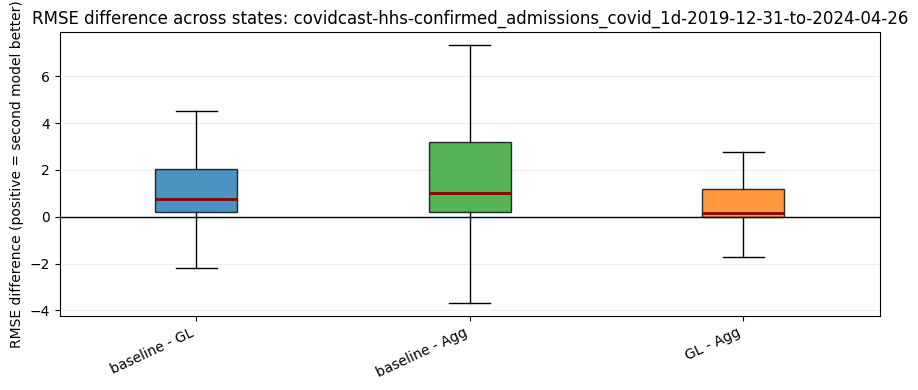

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

sig = pred_df["target_signal"].iloc[0]
df_sig = pred_df[pred_df["target_signal"] == sig].copy()

# per-state RMSE for each model (across ALL test points in pred_df)
rmse_state = (
    df_sig.groupby(["geo_value", "model"])
    .apply(lambda g: np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
    .rename("RMSE")
    .reset_index()
)

# wide: rows=state, cols=model
rmse_wide = rmse_state.pivot(index="geo_value", columns="model", values="RMSE")

# choose your model names
BASE = "baseline_AR_decay"
GL   = "SIS_GroupLasso"
AGG  = "SIS_GroupLasso_Agg"

# keep only states with all models present
rmse_wide = rmse_wide[[BASE, GL, AGG]].dropna()

# differences (positive means SECOND is better if you do base - other? depends)
diff_df = pd.DataFrame(index=rmse_wide.index)
diff_df["baseline - GL"]  = rmse_wide[BASE] - rmse_wide[GL]
diff_df["baseline - Agg"] = rmse_wide[BASE] - rmse_wide[AGG]
diff_df["GL - Agg"]       = rmse_wide[GL]   - rmse_wide[AGG]

def get_base_diff(colname: str):
    # here each column is already a base diff label
    return colname

base_diff_to_color = {
    "baseline - GL":  "tab:blue",
    "baseline - Agg": "tab:green",
    "GL - Agg":       "tab:orange",
}

def color_boxes_by_diff(ax, bp, columns):
    for i, box_artist in enumerate(bp["boxes"]):
        colname = columns[i]
        color = base_diff_to_color.get(colname, "lightgray")
        box_artist.set_facecolor(color)
        box_artist.set_edgecolor("black")
        box_artist.set_alpha(0.8)

    for w in bp["whiskers"]:
        w.set(color="black", linewidth=1)
    for c in bp["caps"]:
        c.set(color="black", linewidth=1)
    for m in bp["medians"]:
        m.set(color="darkred", linewidth=2)

# Plot
cols = diff_df.columns.tolist()

fig, ax = plt.subplots(figsize=(9, 4))

bp = ax.boxplot(
    [diff_df[c].values for c in cols],
    labels=cols,
    patch_artist=True,
    showfliers=False
)

color_boxes_by_diff(ax, bp, cols)

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("RMSE difference (positive = second model better)")
ax.set_title(f"RMSE difference across states: {sig}")
ax.grid(True, axis="y", alpha=0.2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


0.03


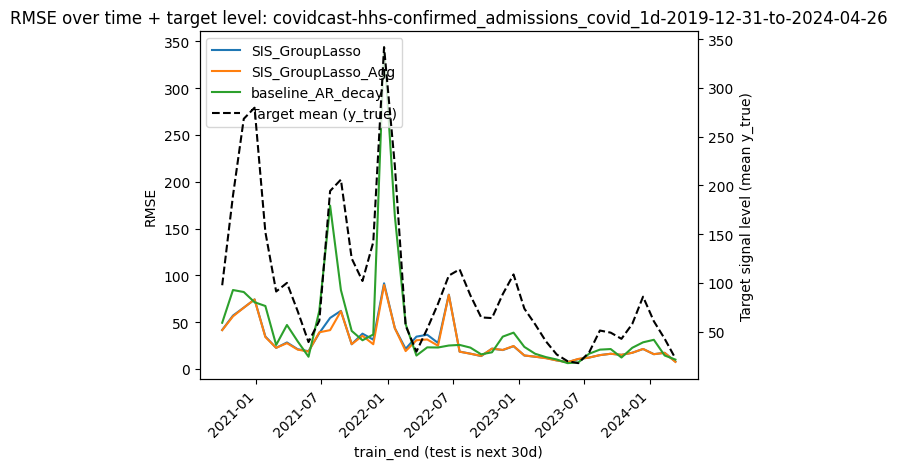

                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  35.768081  16.256137  69660.0  
1  34.732696  15.820425  69660.0  
2  73.715165  22.237709  69660.0  


/tmp/ipykernel_822481/4112563132.py:394: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


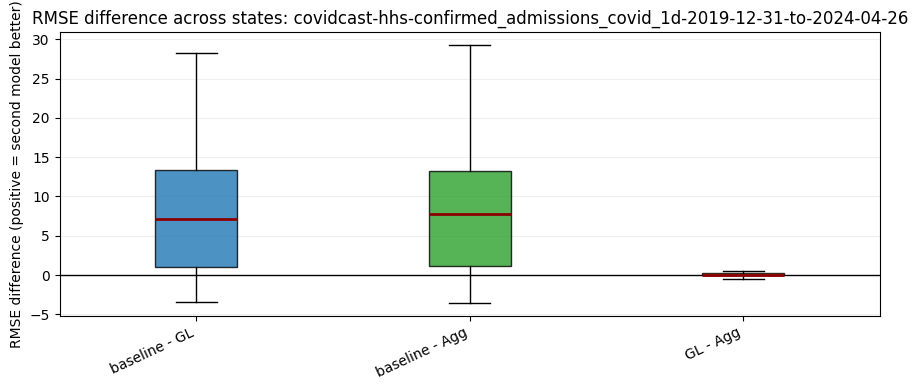

0.05


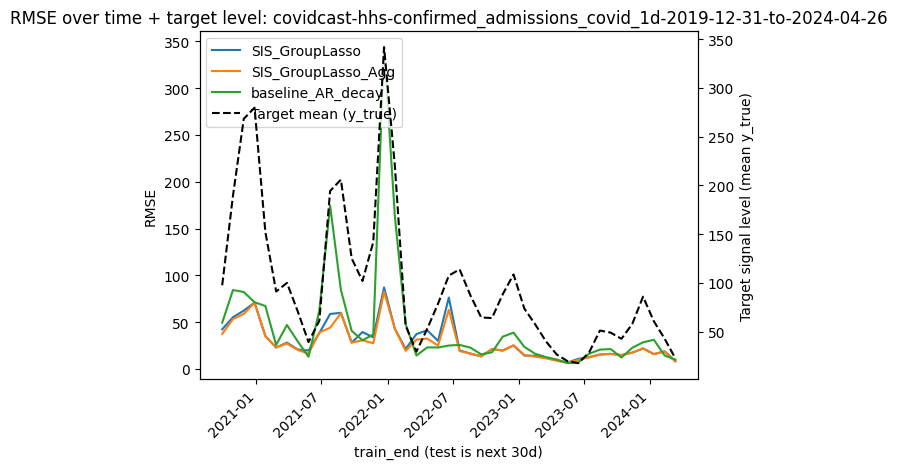

                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  35.492707  16.407565  69660.0  
1  32.814913  15.496688  69660.0  
2  73.715165  22.237709  69660.0  


/tmp/ipykernel_822481/4112563132.py:394: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


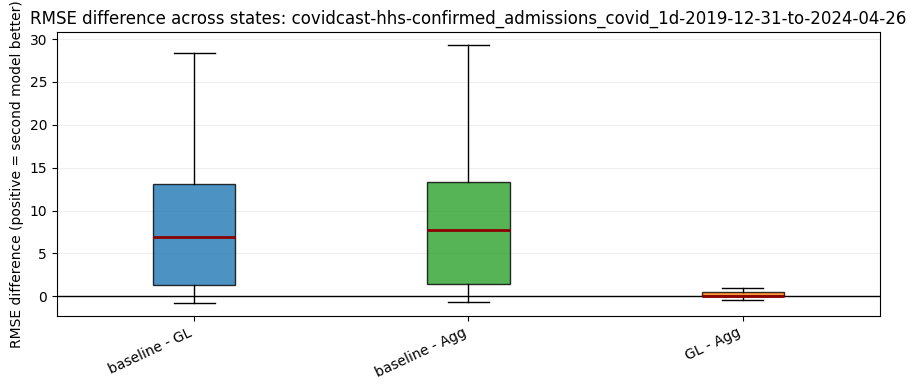

0.07


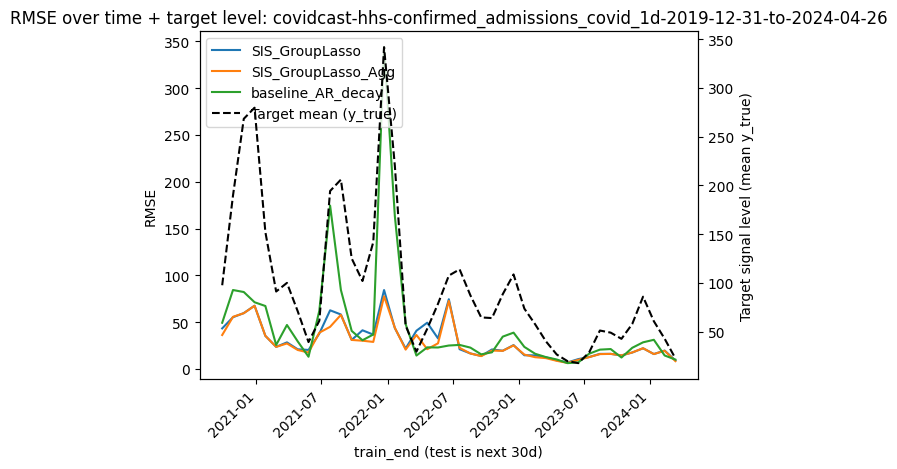

                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  35.770207  16.675216  69660.0  
1  33.033869  15.705497  69660.0  
2  73.715165  22.237709  69660.0  


/tmp/ipykernel_822481/4112563132.py:394: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


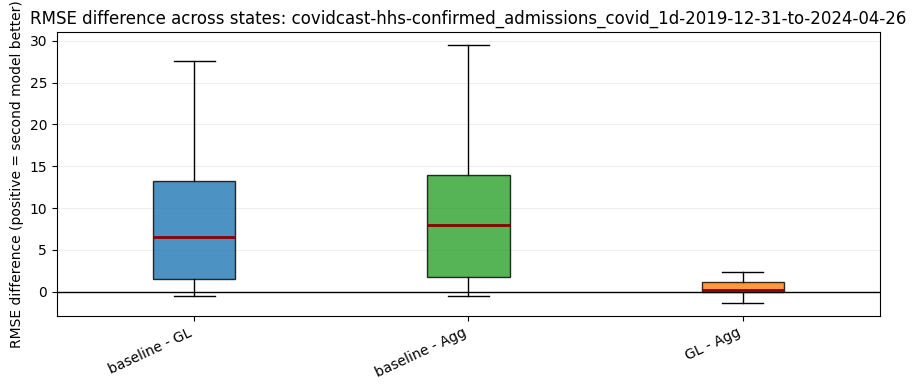

0.1


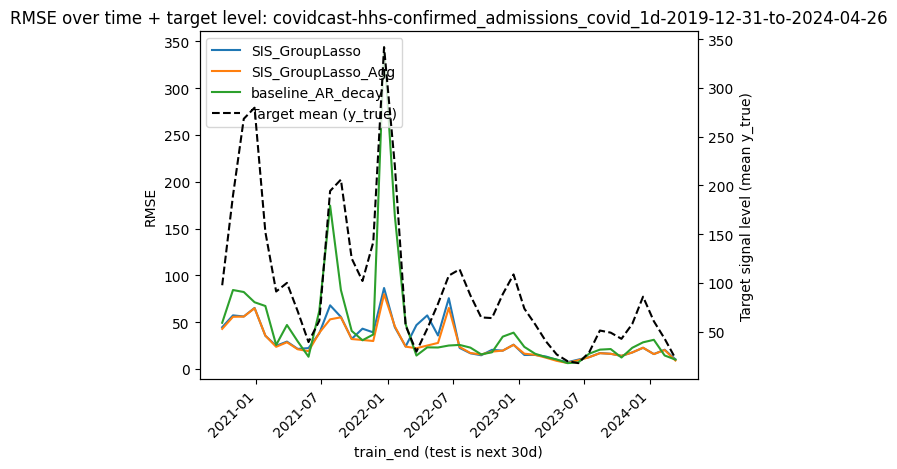

                                       target_signal               model  \
0  covidcast-hhs-confirmed_admissions_covid_1d-20...      SIS_GroupLasso   
1  covidcast-hhs-confirmed_admissions_covid_1d-20...  SIS_GroupLasso_Agg   
2  covidcast-hhs-confirmed_admissions_covid_1d-20...   baseline_AR_decay   

        RMSE        MAE        N  
0  36.778279  17.138128  69660.0  
1  32.986843  15.970377  69660.0  
2  73.715165  22.237709  69660.0  


/tmp/ipykernel_822481/4112563132.py:394: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


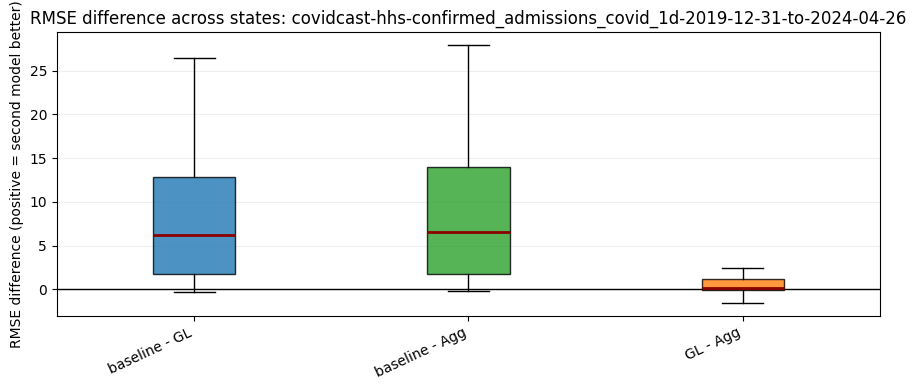

In [17]:
FEATURE_LAGS = (1, 2, 3, 4)
AR_LAGS      = (4, 5, 6, 7)
BASELINE_GAMMAS = [0.0, 0.01, 0.05, 0.1]
K_CANDIDATES = 3
S_SCREEN = 50    # top-s entries in sparsity-index screening
Q_TAU = 1.0       # temperature for Q-aggregation
unit = 'D'
RETRAIN_EVERY = 30
TEST_WINDOW = 30
VAL_WINDOW = 30
TRAIN_WINDOW = 180
target_name = 'covidcast-hhs-confirmed_admissions_covid_1d-2019-12-31-to-2024-04-26'
target_wide = signal_wides[target_name].iloc[92:]
all_signal_wides = {}
for fp in aux_files:
    name = os.path.splitext(os.path.basename(fp))[0]
    all_signal_wides[name] = signal_wides[name]

target_wide = target_wide.sort_index()
target_idx = pd.to_datetime(target_wide.index)
feature_wides_raw = {k: v for k, v in all_signal_wides.items() if k != target_name}
feature_wides = {}
for sig_name, wide in feature_wides_raw.items():
    if wide is None or len(wide) == 0:
        continue
    wide = wide.sort_index().copy()
    wide.index = pd.to_datetime(wide.index)
    wide_aligned = wide.reindex(target_idx)
    wide_aligned = wide_aligned.mask(wide_aligned < 0, 0.0)
    # wide_aligned = wide_aligned.interpolate(method="time", limit=LIMIT_INTERP_DAYS, limit_area="inside")
    # wide_aligned = wide_aligned.ffill(limit=LIMIT_INTERP_DAYS).bfill(limit=LIMIT_INTERP_DAYS)
    wide_aligned = wide_aligned.fillna(0.0)
    nonconstant_cols = (wide_aligned.abs().sum(axis=0) > 0)
    wide_aligned = wide_aligned.loc[:, nonconstant_cols]
    if wide_aligned.shape[1] == 0:
        continue
    feature_wides[sig_name] = wide_aligned

# Determine states common across target + (at least some) features
states = [c for c in target_wide.columns if c.isalpha() and len(c) == 2]  # typical state abbrev
states = [st for st in states if st in target_wide.columns]
if len(states) == 0:
    states = list(target_wide.columns)

train_ends = compute_walkforward_schedule(dates = target_wide.index, train_size = TRAIN_WINDOW, test_size = TEST_WINDOW, retrain_every = RETRAIN_EVERY, unit = unit)

group_size = len(FEATURE_LAGS)
assert len(AR_LAGS) == group_size, "AR_LAGS must have same length as FEATURE_LAGS for equal-size groups."

for GL_ALPHA in [0.03, 0.05, 0.07, 0.1]:
    pred_rows = []
    agg_rows = []
    for train_end in train_ends:
        train_end = pd.to_datetime(train_end)
        train_start = train_end - pd.Timedelta(TRAIN_WINDOW - 1, unit = unit)
        val_start = train_end - pd.Timedelta(VAL_WINDOW - 1, unit = unit)
        test_start = train_end + pd.Timedelta(1, unit = unit)
        test_end = train_end + pd.Timedelta(TEST_WINDOW, unit = unit)

        # Fit GroupLasso for ALL states in this window (target-only training per state)
        # Store coefs/intercepts and d = X^T y / T for candidate selection
        fit_by_state = {}
        d_by_state = {}

        # also store AR-only baseline (gamma chosen per state)
        baseline_by_state = {}

        # Pre-build datasets per state (train/val/test)
        data_cache = {}

        for st in states:
            # build full window design up to test_end so we can slice train/val/test cleanly
            built = build_design_for_state(
                target_wide, feature_wides, st,
                start_date=train_start, end_date=test_end,
                feature_lags=FEATURE_LAGS, ar_lags=AR_LAGS, unit = unit
            )
            if built is None:
                continue
            X_all, y_all, dates_all, feat_names, group_names = built
            data_cache[st] = (X_all, y_all, dates_all, feat_names, group_names)

            # indices for train/val/test within aligned dates_all
            dates_all = pd.to_datetime(dates_all)
            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)

            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ---------- Baseline: AR-only with decay gamma tuned on val ----------
            # AR columns are last len(AR_LAGS) columns by construction
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]
            best_gamma = fit_ar_baseline_decay(
                Xtr_ar, y_tr, Xva_ar, y_va, train_dates=d_tr, train_end=train_end, gammas=BASELINE_GAMMAS
            )
            baseline_by_state[st] = {"gamma": best_gamma}

            # ---------- SIS-GroupLasso fit ----------
            active_g, coef, intercept = SIS_grpLasso_KKT(
                X_expanded=X_tr, y=y_tr,
                group_size=group_size, alpha=GL_ALPHA, weights=None
            )
            fit_by_state[st] = {
                "coef": pd.Series(coef, index=feat_names),
                "intercept": intercept,
                "active_g": active_g
            }

            # d statistic for candidate selection (use training)
            d_by_state[st] = (X_tr.T @ y_tr) / max(len(y_tr), 1)

        if len(fit_by_state) < 2:
            continue

        # Now evaluate per state
        for st in list(fit_by_state.keys()):
            X_all, y_all, dates_all, feat_names, group_names = data_cache[st]
            dates_all = pd.to_datetime(dates_all)

            idx_train = (dates_all >= train_start) & (dates_all <= train_end)
            idx_val   = (dates_all >= val_start) & (dates_all <= train_end)
            idx_test  = (dates_all >= test_start) & (dates_all <= test_end)
            if idx_train.sum() < 10 or idx_val.sum() < 2 or idx_test.sum() < 2:
                continue

            X_tr, y_tr, d_tr = X_all[idx_train], y_all[idx_train], dates_all[idx_train]
            X_va, y_va = X_all[idx_val], y_all[idx_val]
            X_te, y_te, d_te = X_all[idx_test], y_all[idx_test], dates_all[idx_test]

            # ----- Baseline predictions -----
            ar_cols = np.arange(X_all.shape[1] - len(AR_LAGS), X_all.shape[1])
            Xtr_ar, Xva_ar, Xte_ar = X_tr[:, ar_cols], X_va[:, ar_cols], X_te[:, ar_cols]

            g = baseline_by_state[st]["gamma"]
            backcast_lag = (train_end - d_tr).days.astype(float).values
            w = np.exp(-g * backcast_lag)
            w = w / (w.max() if w.max() > 0 else 1.0)
            yhat_base = weighted_ols_fit_predict(Xtr_ar, y_tr, w, Xte_ar)

            # ----- SIS-GroupLasso target-only predictions -----
            target_feat_names = feat_names
            fit0 = fit_by_state[st]
            yhat_gl = predict_named(X_te, target_feat_names, fit0["coef"], fit0["intercept"])

            # ----- Aggregation -----
            # candidate states via sparsity index
            # all_states_here = [s for s in fit_by_state.keys() if s in d_by_state]
            all_states_here = [s for s in fit_by_state.keys() if s in d_by_state and s in VALID_STATES]
            cand_states = select_candidate_states(d_by_state, st, all_states_here, s=S_SCREEN, K=K_CANDIDATES)
            cand_all = [st] + cand_states

            # build Yhat on validation (on target state's X_va) and test (on target state's X_te)
            Yhat_val = []
            Yhat_test = []
            for s2 in cand_all:
                fit2 = fit_by_state[s2]
                Yhat_val.append(predict_named(X_va, target_feat_names, fit2["coef"], fit2["intercept"]))
                Yhat_test.append(predict_named(X_te, target_feat_names, fit2["coef"], fit2["intercept"]))
            Yhat_val = np.column_stack(Yhat_val)
            Yhat_test = np.column_stack(Yhat_test)

            w_agg = q_aggregate_weights(y_va, Yhat_val, total_step=10, selection=False, eps=1e-3)
            yhat_agg = Yhat_test @ w_agg
            for j, s2 in enumerate(cand_all):
                agg_rows.append({
                    "target_signal": target_name,
                    "target_state": st,
                    "train_end": train_end.date().isoformat(),
                    "candidate_state": s2,
                    "is_self": (j == 0),
                    "rank": j,                 # 0=self, 1..K are candidates
                    "weight": float(w_agg[j])  # weight for this candidate in Q-agg
                })
            for i, dt in enumerate(d_te):
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "baseline_AR_decay",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_base[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_gl[i]),
                })
                pred_rows.append({
                    "target_signal": target_name,
                    "geo_value": st,
                    "train_end": train_end.date().isoformat(),
                    "time_value": dt.date().isoformat(),
                    "model": "SIS_GroupLasso_Agg",
                    "y_true": float(y_te[i]),
                    "y_pred": float(yhat_agg[i]),
                })
    print(GL_ALPHA)
    pred_df = pd.DataFrame(pred_rows)
    agg_df = pd.DataFrame(agg_rows)
    agg_df["train_end"] = pd.to_datetime(agg_df["train_end"])
    # summary metrics
    summary = (
        pred_df.groupby(["target_signal", "model", "geo_value"])
        .apply(lambda g: pd.Series({
            "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
            "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
            "N": len(g)
        }))
        .reset_index()
    )

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    pred_df["train_end"] = pd.to_datetime(pred_df["train_end"])
    pred_df["time_value"] = pd.to_datetime(pred_df["time_value"])

    def rmse(x):
        return np.sqrt(np.mean((x["y_true"].values - x["y_pred"].values) ** 2))

    # A) RMSE per retrain step (each step = next 30-day test period)
    rmse_by_step = (
        pred_df
        .groupby(["target_signal", "model", "train_end"])
        .apply(rmse)
        .rename("RMSE")
        .reset_index()
        .sort_values(["target_signal", "model", "train_end"])
    )

    sig = pred_df["target_signal"].iloc[0]
    tmp = rmse_by_step[rmse_by_step["target_signal"] == sig].copy()

    # Build a "target level" series aligned to train_end:
    # use mean(y_true) over the corresponding test block (all states pooled)
    target_level = (
        pred_df[pred_df["target_signal"] == sig]
        .groupby("train_end")["y_true"]
        .mean()
        .rename("target_mean")
        .reset_index()
    )

    # Merge so x-axis aligns
    tmp2 = tmp.merge(target_level, on="train_end", how="left")

    fig, ax = plt.subplots()

    # left axis: RMSE by model
    for m, g in tmp2.groupby("model"):
        ax.plot(g["train_end"], g["RMSE"], label=m)
    ax.set_xlabel("train_end (test is next 30d)")
    ax.set_ylabel("RMSE")

    # right axis: target signal level
    ax2 = ax.twinx()
    ax2.plot(target_level["train_end"], target_level["target_mean"], color = 'k', linestyle="--", label="Target mean (y_true)")
    ax2.set_ylabel("Target signal level (mean y_true)")

    # combined legend (both axes)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    ax.set_title(f"RMSE over time + target level: {sig}")
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()


    print(pred_df.groupby(["target_signal", "model"]).apply(lambda g: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
        "N": len(g)
    })).reset_index())

    # exclude self
    cand_only = agg_df[~agg_df["is_self"]].copy()

    # frequency table
    freq = (
        cand_only
        .groupby(["target_signal", "target_state", "candidate_state"])
        .size()
        .rename("count")
        .reset_index()
    )

    from collections import defaultdict

    def most_frequent_candidates_dict(agg_df, top_k=5, drop_self=True, min_count=1):
        df = agg_df.copy()

        if drop_self and "is_self" in df.columns:
            df = df[~df["is_self"]]

        # frequency count
        freq = (
            df.groupby(["target_state", "candidate_state"])
            .size()
            .rename("count")
            .reset_index()
        )

        # filter low counts if wanted
        freq = freq[freq["count"] >= min_count]

        # build dict: state -> list of top_k candidates
        out = {}
        for st, g in freq.sort_values(["target_state", "count"], ascending=[True, False]).groupby("target_state"):
            out[st] = g["candidate_state"].head(top_k).tolist()

        return out

    # usage:
    top_candidates = most_frequent_candidates_dict(agg_df, top_k=5)
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from sklearn.metrics import mean_squared_error

    sig = pred_df["target_signal"].iloc[0]
    df_sig = pred_df[pred_df["target_signal"] == sig].copy()

    # per-state RMSE for each model (across ALL test points in pred_df)
    rmse_state = (
        df_sig.groupby(["geo_value", "model"])
        .apply(lambda g: np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
        .rename("RMSE")
        .reset_index()
    )

    # wide: rows=state, cols=model
    rmse_wide = rmse_state.pivot(index="geo_value", columns="model", values="RMSE")

    # choose your model names
    BASE = "baseline_AR_decay"
    GL   = "SIS_GroupLasso"
    AGG  = "SIS_GroupLasso_Agg"

    # keep only states with all models present
    rmse_wide = rmse_wide[[BASE, GL, AGG]].dropna()

    # differences (positive means SECOND is better if you do base - other? depends)
    diff_df = pd.DataFrame(index=rmse_wide.index)
    diff_df["baseline - GL"]  = rmse_wide[BASE] - rmse_wide[GL]
    diff_df["baseline - Agg"] = rmse_wide[BASE] - rmse_wide[AGG]
    diff_df["GL - Agg"]       = rmse_wide[GL]   - rmse_wide[AGG]

    def get_base_diff(colname: str):
        # here each column is already a base diff label
        return colname

    base_diff_to_color = {
        "baseline - GL":  "tab:blue",
        "baseline - Agg": "tab:green",
        "GL - Agg":       "tab:orange",
    }

    def color_boxes_by_diff(ax, bp, columns):
        for i, box_artist in enumerate(bp["boxes"]):
            colname = columns[i]
            color = base_diff_to_color.get(colname, "lightgray")
            box_artist.set_facecolor(color)
            box_artist.set_edgecolor("black")
            box_artist.set_alpha(0.8)

        for w in bp["whiskers"]:
            w.set(color="black", linewidth=1)
        for c in bp["caps"]:
            c.set(color="black", linewidth=1)
        for m in bp["medians"]:
            m.set(color="darkred", linewidth=2)

    # Plot
    cols = diff_df.columns.tolist()

    fig, ax = plt.subplots(figsize=(9, 4))

    bp = ax.boxplot(
        [diff_df[c].values for c in cols],
        labels=cols,
        patch_artist=True,
        showfliers=False
    )

    color_boxes_by_diff(ax, bp, cols)

    ax.axhline(0, color="black", linewidth=1)
    ax.set_ylabel("RMSE difference (positive = second model better)")
    ax.set_title(f"RMSE difference across states: {sig}")
    ax.grid(True, axis="y", alpha=0.2)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_822481/2968602586.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


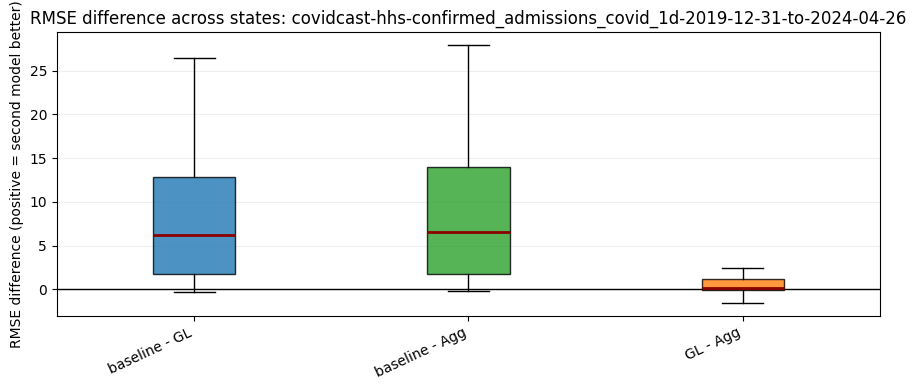

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

sig = pred_df["target_signal"].iloc[0]
df_sig = pred_df[pred_df["target_signal"] == sig].copy()

# per-state RMSE for each model (across ALL test points in pred_df)
rmse_state = (
    df_sig.groupby(["geo_value", "model"])
    .apply(lambda g: np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
    .rename("RMSE")
    .reset_index()
)

# wide: rows=state, cols=model
rmse_wide = rmse_state.pivot(index="geo_value", columns="model", values="RMSE")

# choose your model names
BASE = "baseline_AR_decay"
GL   = "SIS_GroupLasso"
AGG  = "SIS_GroupLasso_Agg"

# keep only states with all models present
rmse_wide = rmse_wide[[BASE, GL, AGG]].dropna()

# differences (positive means SECOND is better if you do base - other? depends)
diff_df = pd.DataFrame(index=rmse_wide.index)
diff_df["baseline - GL"]  = rmse_wide[BASE] - rmse_wide[GL]
diff_df["baseline - Agg"] = rmse_wide[BASE] - rmse_wide[AGG]
diff_df["GL - Agg"]       = rmse_wide[GL]   - rmse_wide[AGG]

def get_base_diff(colname: str):
    # here each column is already a base diff label
    return colname

base_diff_to_color = {
    "baseline - GL":  "tab:blue",
    "baseline - Agg": "tab:green",
    "GL - Agg":       "tab:orange",
}

def color_boxes_by_diff(ax, bp, columns):
    for i, box_artist in enumerate(bp["boxes"]):
        colname = columns[i]
        color = base_diff_to_color.get(colname, "lightgray")
        box_artist.set_facecolor(color)
        box_artist.set_edgecolor("black")
        box_artist.set_alpha(0.8)

    for w in bp["whiskers"]:
        w.set(color="black", linewidth=1)
    for c in bp["caps"]:
        c.set(color="black", linewidth=1)
    for m in bp["medians"]:
        m.set(color="darkred", linewidth=2)

# Plot
cols = diff_df.columns.tolist()

fig, ax = plt.subplots(figsize=(9, 4))

bp = ax.boxplot(
    [diff_df[c].values for c in cols],
    labels=cols,
    patch_artist=True,
    showfliers=False
)

color_boxes_by_diff(ax, bp, cols)

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("RMSE difference (positive = second model better)")
ax.set_title(f"RMSE difference across states: {sig}")
ax.grid(True, axis="y", alpha=0.2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
